In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
data = {
    "hours_studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "sleep_hours":   [5, 6, 6, 7, 7, 8, 8, 7, 8, 9, 8, 9],
    "exam_score": [50, 56, 61, 67, 72, 78, 83, 85, 90, 96, 97, 60]
}

df = pd.DataFrame(data)
df

,hours_studied,sleep_hours,exam_score
0,1,5,50
1,2,6,56
2,3,6,61
3,4,7,67
4,5,7,72
5,6,8,78
6,7,8,83
7,8,7,85
8,9,8,90
9,10,9,96


In [4]:
X = df[['hours_studied', 'sleep_hours']]
y = df['exam_score']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state = 42
)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
predictions = model.predict(X_test)

predictions

array([79.3559322 , 78.92655367, 63.45762712])

In [8]:
results = pd.DataFrame({
    "real_score": y_test,
    "predicted_score": predictions,
    "error": y_test - predictions,
    "absolute_error": abs(y_test - predictions)
})

results

,real_score,predicted_score,error,absolute_error
10,97,79.355932,17.644068,17.644068
9,96,78.926554,17.073446,17.073446
0,50,63.457627,-13.457627,13.457627


In [9]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 16.06
MSE: 261.31
RMSE: 16.17
R²: 0.46


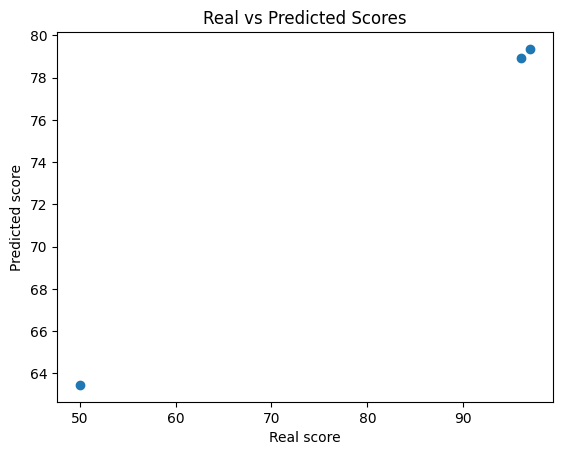

In [10]:
plt.scatter(y_test, predictions)

plt.xlabel("Real score")
plt.ylabel("Predicted score")
plt.title("Real vs Predicted Scores")

plt.show()